In [1]:
! git clone https://github.com/tapichugina/Simple_Pytorch_Img_Project.git
! pip install torchinfo

Cloning into 'Simple_Pytorch_Img_Project'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 64 (delta 23), reused 42 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 10.75 MiB | 11.89 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
import torchvision
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau,MultiStepLR, CyclicLR, LambdaLR
from torch.utils.data import Dataset, DataLoader,WeightedRandomSampler
import torchvision.datasets as datasets
from torchvision.transforms.v2 import Compose, Normalize,Resize,ToImage,ToDtype,RandomCrop,RandomHorizontalFlip
from torch.utils.data import random_split
from torchinfo import summary

from sklearn.metrics import f1_score, confusion_matrix, classification_report



from pathlib import Path
import sys
PROJECT_ROOT = Path("/content/Simple_Pytorch_Img_Project")
sys.path.insert(0, str(PROJECT_ROOT))

from utils.train import StepByStep
from utils.overfit_single_batch import overfit_single_batch
from utils.calculate_img_statistics import calculate_statistics

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Data_Folder="/content/drive/MyDrive/Image_Classification/data/CIFAR10"
Runs_Folder="/content/drive/MyDrive/Image_Classification/runs"
Log_Folder="/content/drive/MyDrive/Image_Classification/logs"
Checkpoints_Folder="/content/drive/MyDrive/Image_Classification/checkpoints"

Mounted at /content/drive


In [4]:
# # %load_ext autoreload
# # %autoreload 2

# import importlib
# import utils.train

# importlib.reload(utils.train)


# Data

### CIFAR

size of single image
32x32x3

* Train 50000
* Test  10000


0. 'airplane',
1. 'automobile',
2. 'bird',
3. 'cat',
4. 'deer',
5. 'dog',
6. 'frog',
7. 'horse',
8. 'ship',
9. 'truck'

In [5]:
transform_train = Compose([
    RandomCrop(32, padding=4),
    RandomHorizontalFlip(),
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

transform_val = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])


train_dataset = torchvision.datasets.CIFAR10(
    root=Data_Folder,
    train=True,
    transform=transform_train,
    download=False
)

test_dataset = torchvision.datasets.CIFAR10(
    root=Data_Folder,
    train=False,
    transform=transform_val,
    download=False
)

In [6]:
train_loader=DataLoader(train_dataset,batch_size=128,shuffle=True)
val_loader=DataLoader(test_dataset,batch_size=128,shuffle=False)

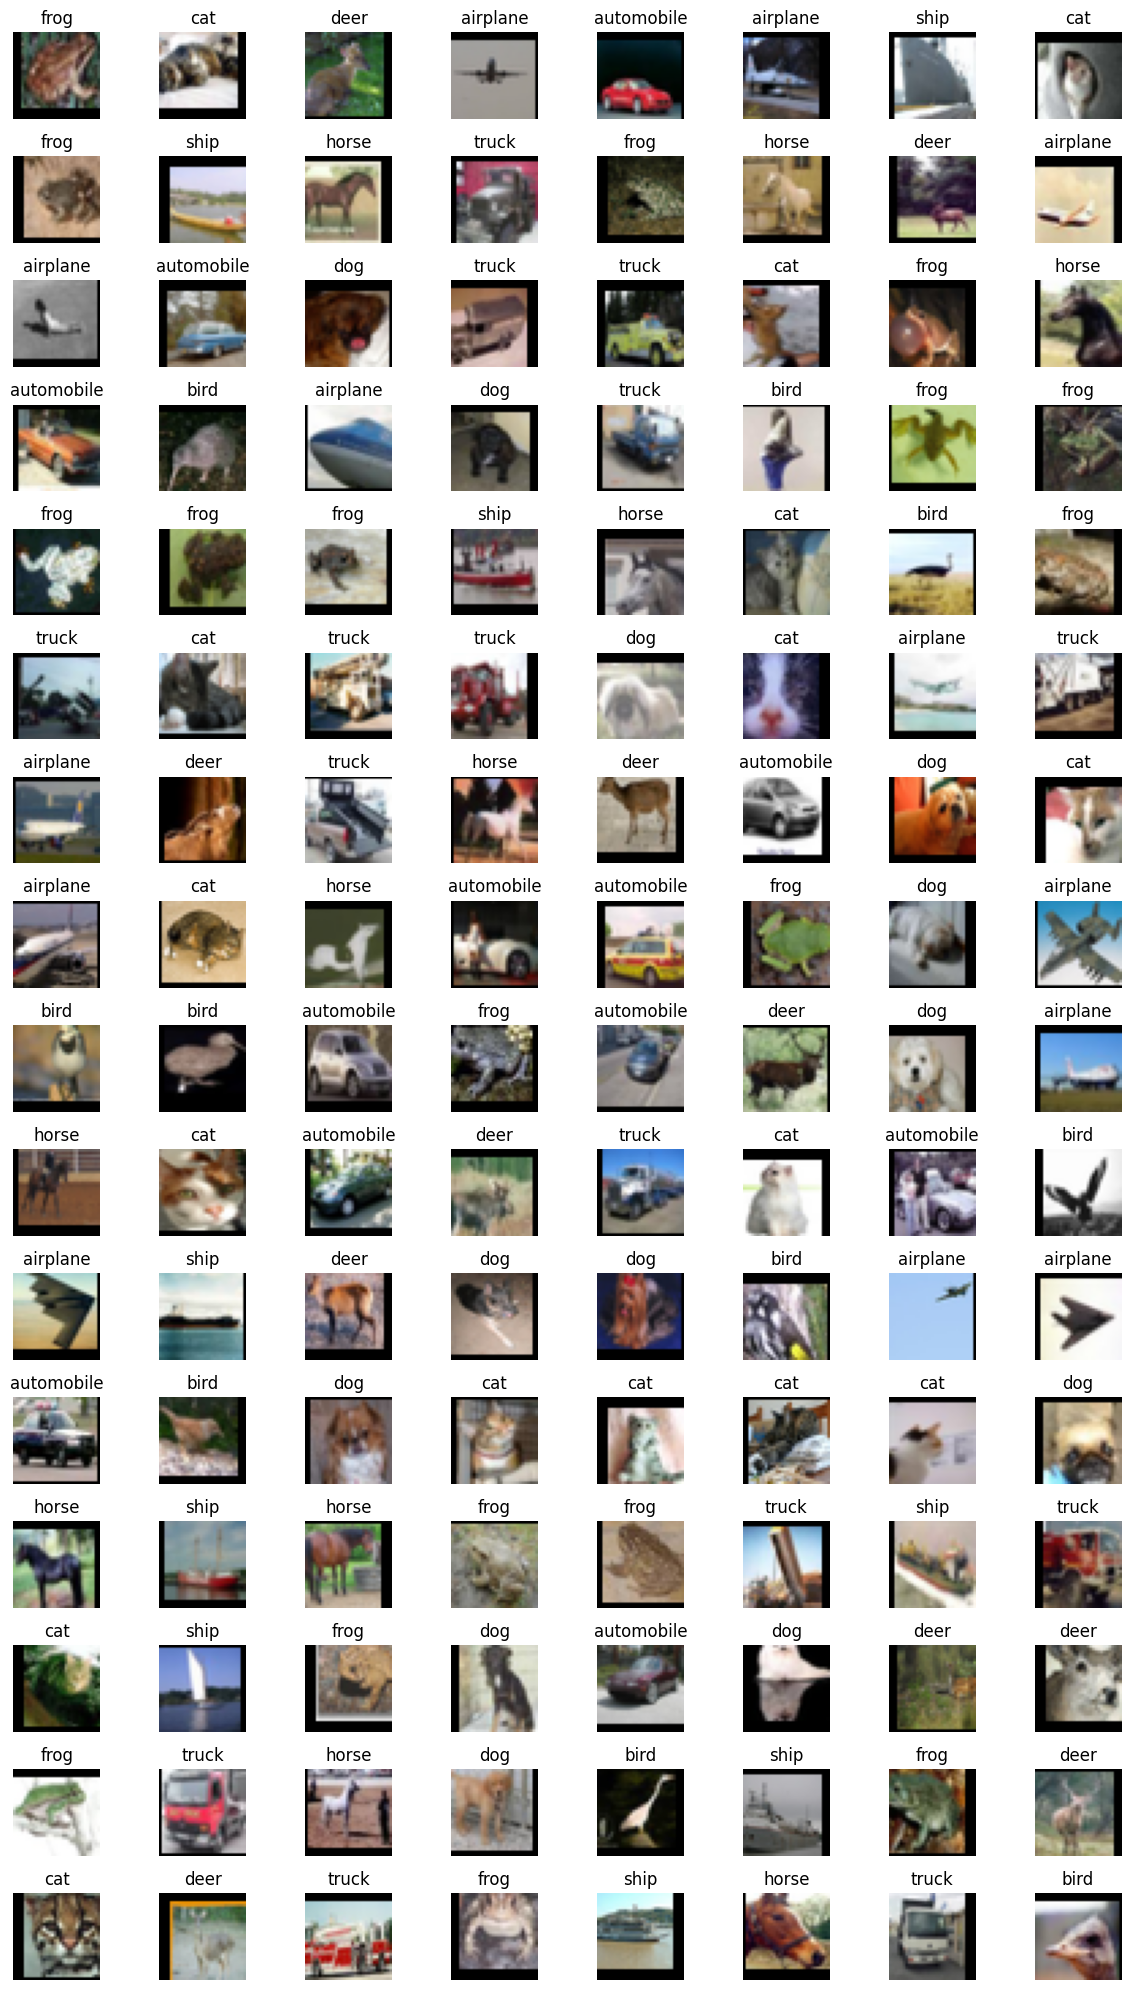

In [7]:
batch, labels = next(iter(train_loader))

mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

# Undo normalization
batch = batch * std + mean


fig, axes = plt.subplots(16, 8, figsize=(12, 20))

for image, label, ax in zip(batch, labels, axes.flat):
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()


## Model

In [8]:
def vgg_block(num_convs, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size=3, padding=1,bias=False))
        layers.append(nn.LazyBatchNorm2d())
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)


In [12]:
class small_VGG(nn.Module):
    def __init__(self, arch, num_classes=10):
        super().__init__()

        conv_blks = []
        for (num_convs, out_channels) in arch:
            conv_blks.append(vgg_block(num_convs, out_channels))
        self.net = nn.Sequential(
            *conv_blks,
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.LazyLinear(128),nn.ReLU(), nn.Dropout(0.3),
            nn.LazyLinear(64),nn.ReLU(), nn.Dropout(0.3),
            nn.LazyLinear(num_classes))

    def forward(self, X):
        return self.net(X)

In [13]:
torch.manual_seed(13)
arch=((1,32),(2,64),(2,128),(2, 256))

model=small_VGG(arch)
x=torch.rand(1,3,32,32)
model(x)
summary(model, input_size=(1, 3, 32, 32))


Layer (type:depth-idx)                   Output Shape              Param #
small_VGG                                [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Sequential: 2-1                   [1, 32, 16, 16]           --
│    │    └─Conv2d: 3-1                  [1, 32, 32, 32]           896
│    │    └─BatchNorm2d: 3-2             [1, 32, 32, 32]           64
│    │    └─ReLU: 3-3                    [1, 32, 32, 32]           --
│    │    └─MaxPool2d: 3-4               [1, 32, 16, 16]           --
│    └─Sequential: 2-2                   [1, 64, 8, 8]             --
│    │    └─Conv2d: 3-5                  [1, 64, 16, 16]           18,496
│    │    └─BatchNorm2d: 3-6             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-7                    [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-8                  [1, 64, 16, 16]           36,928
│    │    └─BatchNorm2d: 3-9             [1, 64, 16, 16]           128
│   

In [17]:
RunName="small_VGG_v4_batchnorm_optimizer"
loss=nn.CrossEntropyLoss(reduction='mean')
#optimizer=optim.AdamW(model.parameters(),lr=3e-4,weight_decay=1e-2)
optimizer=optim.SGD(model.parameters(),lr=0.01,momentum=0.9)
#scheduler=StepLR(optimizer,step_size=5,gamma=0.5)

sbs=StepByStep(model,loss,optimizer)
sbs.set_loaders(train_loader,val_loader)
sbs.set_tensorboard(RunName,Runs_Folder)


In [18]:
# layers_to_hook = [
#     "net.0.0",   # Conv2d(3, 16, ...)
#     "net.1.0",   # Conv2d(16, 32, ...)
#     "net.2.0",   # Conv2d(32, 64, ...)
#     "net.4",     # Linear(4096, 4096, ...)
#     "net.10"     # Linear(4096, 10, ...)
# ]
# print(layers_to_hook)

# df=sbs.diagnostic_epoch(sbs.train_loader,layers_to_hook=layers_to_hook)
# summary=sbs.summarize_epoch(df)
# summary.to_csv(f"{RunName}_after_1 epoch_calculation.csv")
# print(summary)

In [ ]:
sbs.train(15)
sbs.save_checkpoint(f"{Checkpoints_Folder}/checkpoint-{RunName}.pth")

Epoch [0/15] -> Train Loss: 0.4173 | Val Loss: 0.5175 | F1_ score: 0.8309
Epoch [1/15] -> Train Loss: 0.4018 | Val Loss: 0.4849 | F1_ score: 0.8460
Epoch [2/15] -> Train Loss: 0.3857 | Val Loss: 0.4472 | F1_ score: 0.8571
Epoch [3/15] -> Train Loss: 0.3730 | Val Loss: 0.5004 | F1_ score: 0.8339
Epoch [4/15] -> Train Loss: 0.3590 | Val Loss: 0.5368 | F1_ score: 0.8357
Epoch [5/15] -> Train Loss: 0.3483 | Val Loss: 0.5295 | F1_ score: 0.8303
Epoch [6/15] -> Train Loss: 0.3288 | Val Loss: 0.4509 | F1_ score: 0.8566
Epoch [7/15] -> Train Loss: 0.3236 | Val Loss: 0.5638 | F1_ score: 0.8320
Epoch [8/15] -> Train Loss: 0.3129 | Val Loss: 0.4636 | F1_ score: 0.8571
Epoch [9/15] -> Train Loss: 0.2993 | Val Loss: 0.4423 | F1_ score: 0.8640
Epoch [10/15] -> Train Loss: 0.2972 | Val Loss: 0.4253 | F1_ score: 0.8625
Epoch [11/15] -> Train Loss: 0.2829 | Val Loss: 0.4355 | F1_ score: 0.8657


In [30]:
sbs.val_report[3]['cm']

array([[600,  24,  86,  14,  12,  28,  10,  24, 149,  53],
       [ 22, 677,   2,  18,   8,  22,  13,  17,  35, 186],
       [ 92,   3, 193, 116, 201, 160, 166,  50,  13,   6],
       [ 17,   9,  57, 181,  53, 527,  88,  54,   7,   7],
       [ 33,   4,  38,  40, 463, 126, 122, 166,   4,   4],
       [ 12,   5,  22,  81,  60, 743,  18,  55,   2,   2],
       [  3,   2,  30,  97, 117,  72, 671,   4,   4,   0],
       [ 20,   0,  18,  16,  73, 180,   3, 673,   1,  16],
       [238,  68,  27,  18,   7,  15,  18,   8, 577,  24],
       [ 50, 115,   2,  10,  17,  21,   8,  60,  23, 694]])

In [ ]:
# %load_ext tensorboard
# %tensorboard --logdir "$Runs_Folder"

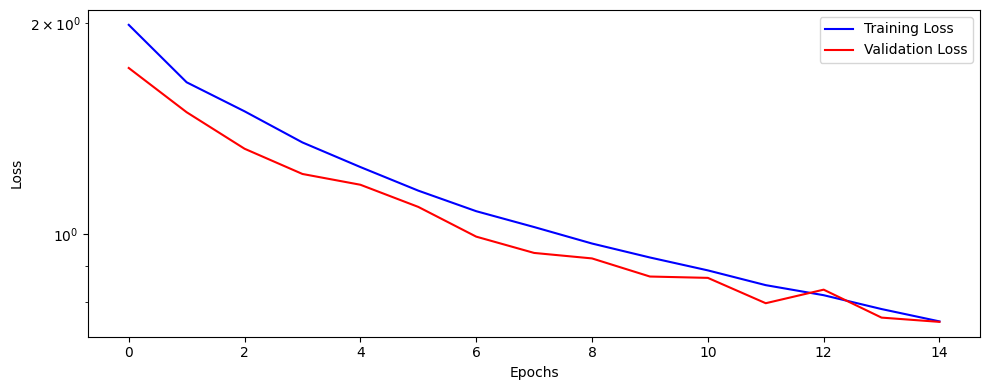

In [31]:
sbs.plot_losses();